# Stage 1 — Lesion Segmentation (U-Net)
### ISIC 2018 Segmentation Dataset → binary lesion masks

This notebook trains a U-Net to segment lesions from the ISIC 2018 segmentation
dataset (images + binary ground-truth masks). The best checkpoint (by validation
Dice) is exported as a **Kaggle Dataset** so the second notebook
(`classification-pipeline.ipynb`) can load it, run inference on every ISIC 2019
image, and use the resulting masks to crop/mask lesions before classification.

**Kaggle setup**
- Add Kaggle dataset: `ISIC 2018 Task 1` (lesion boundary segmentation) as input.
- Settings → Accelerator: GPU, Internet: On.
- Expected input layout (edit `CONFIG["data_root"]` if yours differs):
```
/kaggle/input/isic2018-segmentation/
    ISIC2018_Task1-2_Training_Input/         *.jpg
    ISIC2018_Task1_Training_GroundTruth/     *_segmentation.png
    ISIC2018_Task1-2_Validation_Input/       *.jpg   (optional)
    ISIC2018_Task1_Validation_GroundTruth/   *_segmentation.png (optional)
```
Output artifacts land in `/kaggle/working/artifacts_seg/` — after the run, click
"Save Version" and then create a new Kaggle Dataset from that output folder so
the classification notebook can attach it as an input.


## 0. Setup

In [1]:

import sys, subprocess, importlib
for pkg, mod in [("albumentations", "albumentations"), ("timm", "timm")]:
    if importlib.util.find_spec(mod) is None:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg])

import os, json, random, math, glob
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import cv2
cv2.setNumThreads(0)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2

SEED = 42
def set_seed(seed=SEED):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
set_seed()

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)


Using device: cuda


## 1. Configuration

In [2]:

CONFIG = {
    "data_root": "/kaggle/input/datasets/trantoanthang/isic-2018",
    "train_images_dir": "data/images/train",
    "train_masks_dir": "data/annotations/train",
    "val_images_dir": "data/images/val",     # set to None if you don't have an official val split
    "val_masks_dir": "data/annotations/val",  # and we'll carve val out of train instead
    "test_images_dir": "data/images/test",          # set to None if your dataset mirror has no test ground truth
    "test_masks_dir": "data/annotations/test",
    "output_dir": "/kaggle/working/artifacts_seg",
    "img_size": 384,
    "val_fraction": 0.15,   # used only if no official val dir
    "batch_size": 8,
    "num_workers": 2,
    "lr": 1e-4,
    "weight_decay": 1e-4,
    "max_epochs": 200,
    "early_stop_patience": 25,
    "bce_weight": 0.5,
    "dice_weight": 0.5,
}

Path(CONFIG["output_dir"]).mkdir(parents=True, exist_ok=True)
DATA_ROOT = Path(CONFIG["data_root"])
IMG_SIZE = CONFIG["img_size"]
print(json.dumps(CONFIG, indent=2))


{
  "data_root": "/kaggle/input/datasets/trantoanthang/isic-2018",
  "train_images_dir": "data/images/train",
  "train_masks_dir": "data/annotations/train",
  "val_images_dir": "data/images/val",
  "val_masks_dir": "data/annotations/val",
  "test_images_dir": "data/images/test",
  "test_masks_dir": "data/annotations/test",
  "output_dir": "/kaggle/working/artifacts_seg",
  "img_size": 384,
  "val_fraction": 0.15,
  "batch_size": 8,
  "num_workers": 2,
  "lr": 0.0001,
  "weight_decay": 0.0001,
  "max_epochs": 200,
  "early_stop_patience": 25,
  "bce_weight": 0.5,
  "dice_weight": 0.5
}


## 2. Build file list (image ↔ mask pairing)

In [3]:

def list_pairs(images_dir, masks_dir):
    images_dir = DATA_ROOT / images_dir
    masks_dir = DATA_ROOT / masks_dir
    img_paths = sorted([p for p in images_dir.glob("*.jpg")])
    pairs = []
    for ip in img_paths:
        stem = ip.stem  # e.g. ISIC_0000000
        mask_path = masks_dir / f"{stem}_segmentation.png"
        if mask_path.exists():
            pairs.append((str(ip), str(mask_path)))
    return pairs

train_pairs_all = list_pairs(CONFIG["train_images_dir"], CONFIG["train_masks_dir"])
print(f"Found {len(train_pairs_all)} train image/mask pairs")

has_official_val = (
    CONFIG["val_images_dir"] is not None
    and (DATA_ROOT / CONFIG["val_images_dir"]).exists()
)

if has_official_val:
    train_pairs = train_pairs_all
    val_pairs = list_pairs(CONFIG["val_images_dir"], CONFIG["val_masks_dir"])
else:
    from sklearn.model_selection import train_test_split
    train_pairs, val_pairs = train_test_split(
        train_pairs_all, test_size=CONFIG["val_fraction"], random_state=SEED
    )

print(f"Train pairs: {len(train_pairs)} | Val pairs: {len(val_pairs)}")

has_official_test = (
    CONFIG["test_images_dir"] is not None
    and (DATA_ROOT / CONFIG["test_images_dir"]).exists()
    and (DATA_ROOT / CONFIG["test_masks_dir"]).exists()
)

if has_official_test:
    test_pairs = list_pairs(CONFIG["test_images_dir"], CONFIG["test_masks_dir"])
    print(f"Test pairs: {len(test_pairs)} (official ISIC 2018 test set with released ground truth)")
else:
    test_pairs = []
    print("No official test ground truth found for this dataset mirror — "
          "final reported metric will be the best validation Dice instead.")


Found 2594 train image/mask pairs
Train pairs: 2594 | Val pairs: 100
Test pairs: 1000 (official ISIC 2018 test set with released ground truth)


## 3. Dataset & augmentations

In [4]:

train_tfms = A.Compose([
    A.LongestMaxSize(max_size=IMG_SIZE),
    A.PadIfNeeded(IMG_SIZE, IMG_SIZE, border_mode=cv2.BORDER_CONSTANT, value=0, mask_value=0),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.06, scale_limit=0.15, rotate_limit=25, p=0.6, border_mode=cv2.BORDER_CONSTANT),
    A.RandomBrightnessContrast(p=0.3),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

val_tfms = A.Compose([
    A.LongestMaxSize(max_size=IMG_SIZE),
    A.PadIfNeeded(IMG_SIZE, IMG_SIZE, border_mode=cv2.BORDER_CONSTANT, value=0, mask_value=0),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])


class SegDataset(Dataset):
    def __init__(self, pairs, transform):
        self.pairs = pairs
        self.transform = transform

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_path, mask_path = self.pairs[idx]
        image = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask = (mask > 127).astype(np.float32)
        out = self.transform(image=image, mask=mask)
        image_t = out["image"]
        mask_t = out["mask"].unsqueeze(0).float()
        return image_t, mask_t


train_ds = SegDataset(train_pairs, train_tfms)
val_ds = SegDataset(val_pairs, val_tfms)

train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True,
                           num_workers=CONFIG["num_workers"], pin_memory=True, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False,
                         num_workers=CONFIG["num_workers"], pin_memory=True)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

if has_official_test:
    test_ds = SegDataset(test_pairs, val_tfms)
    test_loader = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False,
                              num_workers=CONFIG["num_workers"], pin_memory=True)
    print(f"Test batches: {len(test_loader)}")


Train batches: 324 | Val batches: 13
Test batches: 125


/tmp/ipykernel_22/3138567570.py:3: UserWarning: Argument(s) 'value, mask_value' are not valid for transform PadIfNeeded
  A.PadIfNeeded(IMG_SIZE, IMG_SIZE, border_mode=cv2.BORDER_CONSTANT, value=0, mask_value=0),
/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/tmp/ipykernel_22/3138567570.py:14: UserWarning: Argument(s) 'value, mask_value' are not valid for transform PadIfNeeded
  A.PadIfNeeded(IMG_SIZE, IMG_SIZE, border_mode=cv2.BORDER_CONSTANT, value=0, mask_value=0),


## 4. U-Net model

In [5]:

class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):
    def __init__(self, in_ch=3, out_ch=1, base=32):
        super().__init__()
        chs = [base, base * 2, base * 4, base * 8, base * 16]
        self.enc1 = ConvBlock(in_ch, chs[0])
        self.enc2 = ConvBlock(chs[0], chs[1])
        self.enc3 = ConvBlock(chs[1], chs[2])
        self.enc4 = ConvBlock(chs[2], chs[3])
        self.bottleneck = ConvBlock(chs[3], chs[4])
        self.pool = nn.MaxPool2d(2)

        self.up4 = nn.ConvTranspose2d(chs[4], chs[3], 2, stride=2)
        self.dec4 = ConvBlock(chs[4], chs[3])
        self.up3 = nn.ConvTranspose2d(chs[3], chs[2], 2, stride=2)
        self.dec3 = ConvBlock(chs[3], chs[2])
        self.up2 = nn.ConvTranspose2d(chs[2], chs[1], 2, stride=2)
        self.dec2 = ConvBlock(chs[2], chs[1])
        self.up1 = nn.ConvTranspose2d(chs[1], chs[0], 2, stride=2)
        self.dec1 = ConvBlock(chs[1], chs[0])

        self.head = nn.Conv2d(chs[0], out_ch, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        b = self.bottleneck(self.pool(e4))

        d4 = self.dec4(torch.cat([self.up4(b), e4], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return self.head(d1)


model = UNet().to(DEVICE)
print(f"U-Net params: {sum(p.numel() for p in model.parameters())/1e6:.1f}M")


U-Net params: 7.8M


## 5. Dice + BCE loss, optimizer, scheduler

In [6]:

def dice_score(logits, targets, eps=1e-6):
    probs = torch.sigmoid(logits)
    probs = (probs > 0.5).float()
    inter = (probs * targets).sum(dim=(1, 2, 3))
    union = probs.sum(dim=(1, 2, 3)) + targets.sum(dim=(1, 2, 3))
    return ((2 * inter + eps) / (union + eps)).mean()


class DiceBCELoss(nn.Module):
    def __init__(self, bce_weight=0.5, dice_weight=0.5):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()
        self.bce_weight = bce_weight
        self.dice_weight = dice_weight

    def forward(self, logits, targets, eps=1e-6):
        bce_loss = self.bce(logits, targets)
        probs = torch.sigmoid(logits)
        inter = (probs * targets).sum(dim=(1, 2, 3))
        union = probs.sum(dim=(1, 2, 3)) + targets.sum(dim=(1, 2, 3))
        dice_loss = 1 - ((2 * inter + eps) / (union + eps)).mean()
        return self.bce_weight * bce_loss + self.dice_weight * dice_loss


criterion = DiceBCELoss(CONFIG["bce_weight"], CONFIG["dice_weight"])
optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG["lr"], weight_decay=CONFIG["weight_decay"])
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["max_epochs"])
scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == "cuda"))


/tmp/ipykernel_22/3046085253.py:28: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == "cuda"))


## 6. Training loop (early stopping on validation Dice)

In [7]:

def run_epoch(loader, train_mode):
    model.train(train_mode)
    total_loss, total_dice, n = 0.0, 0.0, 0
    for images, masks in tqdm(loader, leave=False):
        images, masks = images.to(DEVICE), masks.to(DEVICE)
        with torch.set_grad_enabled(train_mode):
            with torch.cuda.amp.autocast(enabled=(DEVICE.type == "cuda")):
                logits = model(images)
                loss = criterion(logits, masks)
            if train_mode:
                optimizer.zero_grad()
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
        bs = images.size(0)
        total_loss += loss.item() * bs
        total_dice += dice_score(logits.detach(), masks).item() * bs
        n += bs
    return total_loss / n, total_dice / n


best_val_dice = -1.0
patience_counter = 0
history = []

for epoch in range(1, CONFIG["max_epochs"] + 1):
    train_loss, train_dice = run_epoch(train_loader, train_mode=True)
    val_loss, val_dice = run_epoch(val_loader, train_mode=False)
    scheduler.step()

    history.append({"epoch": epoch, "train_loss": train_loss, "train_dice": train_dice,
                     "val_loss": val_loss, "val_dice": val_dice})
    print(f"Epoch {epoch:3d} | train_loss {train_loss:.4f} dice {train_dice:.4f} "
          f"| val_loss {val_loss:.4f} dice {val_dice:.4f}")

    if val_dice > best_val_dice:
        best_val_dice = val_dice
        patience_counter = 0
        torch.save(model.state_dict(), Path(CONFIG["output_dir"]) / "best_unet.pt")
        print(f"  -> new best val Dice {best_val_dice:.4f}, checkpoint saved")
    else:
        patience_counter += 1
        if patience_counter >= CONFIG["early_stop_patience"]:
            print(f"Early stopping at epoch {epoch} (no improvement for {CONFIG['early_stop_patience']} epochs)")
            break

pd.DataFrame(history).to_csv(Path(CONFIG["output_dir"]) / "seg_training_history.csv", index=False)
print(f"Best validation Dice: {best_val_dice:.4f}")


  0%|          | 0/324 [00:00<?, ?it/s]

/tmp/ipykernel_22/2850789502.py:7: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE.type == "cuda")):


  0%|          | 0/13 [00:00<?, ?it/s]

Epoch   1 | train_loss 0.5258 dice 0.6631 | val_loss 0.4237 dice 0.7801
  -> new best val Dice 0.7801, checkpoint saved


  0%|          | 0/324 [00:00<?, ?it/s]

...

Epoch  95 | train_loss 0.0940 dice 0.9032 | val_loss 0.1421 dice 0.8750


  0%|          | 0/324 [00:00<?, ?it/s]

  0%|          | 0/13 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7bcccb504a40>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7bcccb504a40>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Epoch  96 | train_loss 0.0925 dice 0.9047 | val_loss 0.1491 dice 0.8704
Early stopping at epoch 96 (no improvement for 25 epochs)
Best validation Dice: 0.8834


## 7. Held-out test set evaluation

In [8]:

if has_official_test:
    test_loss, test_dice = run_epoch(test_loader, train_mode=False)
    print(f"Test set (official ISIC 2018 test split): loss {test_loss:.4f} | Dice {test_dice:.4f}")
    final_metric = {"split": "test", "loss": test_loss, "dice": test_dice}
else:
    print(f"No official test set available for this mirror. "
          f"Reporting best validation Dice as the final metric: {best_val_dice:.4f}")
    final_metric = {"split": "validation", "loss": None, "dice": best_val_dice}

with open(Path(CONFIG["output_dir"]) / "final_metric.json", "w") as f:
    json.dump(final_metric, f, indent=2)


  0%|          | 0/125 [00:00<?, ?it/s]

/tmp/ipykernel_22/2850789502.py:7: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE.type == "cuda")):


Test set (official ISIC 2018 test split): loss 0.1747 | Dice 0.8613


## 8. Visual sanity check

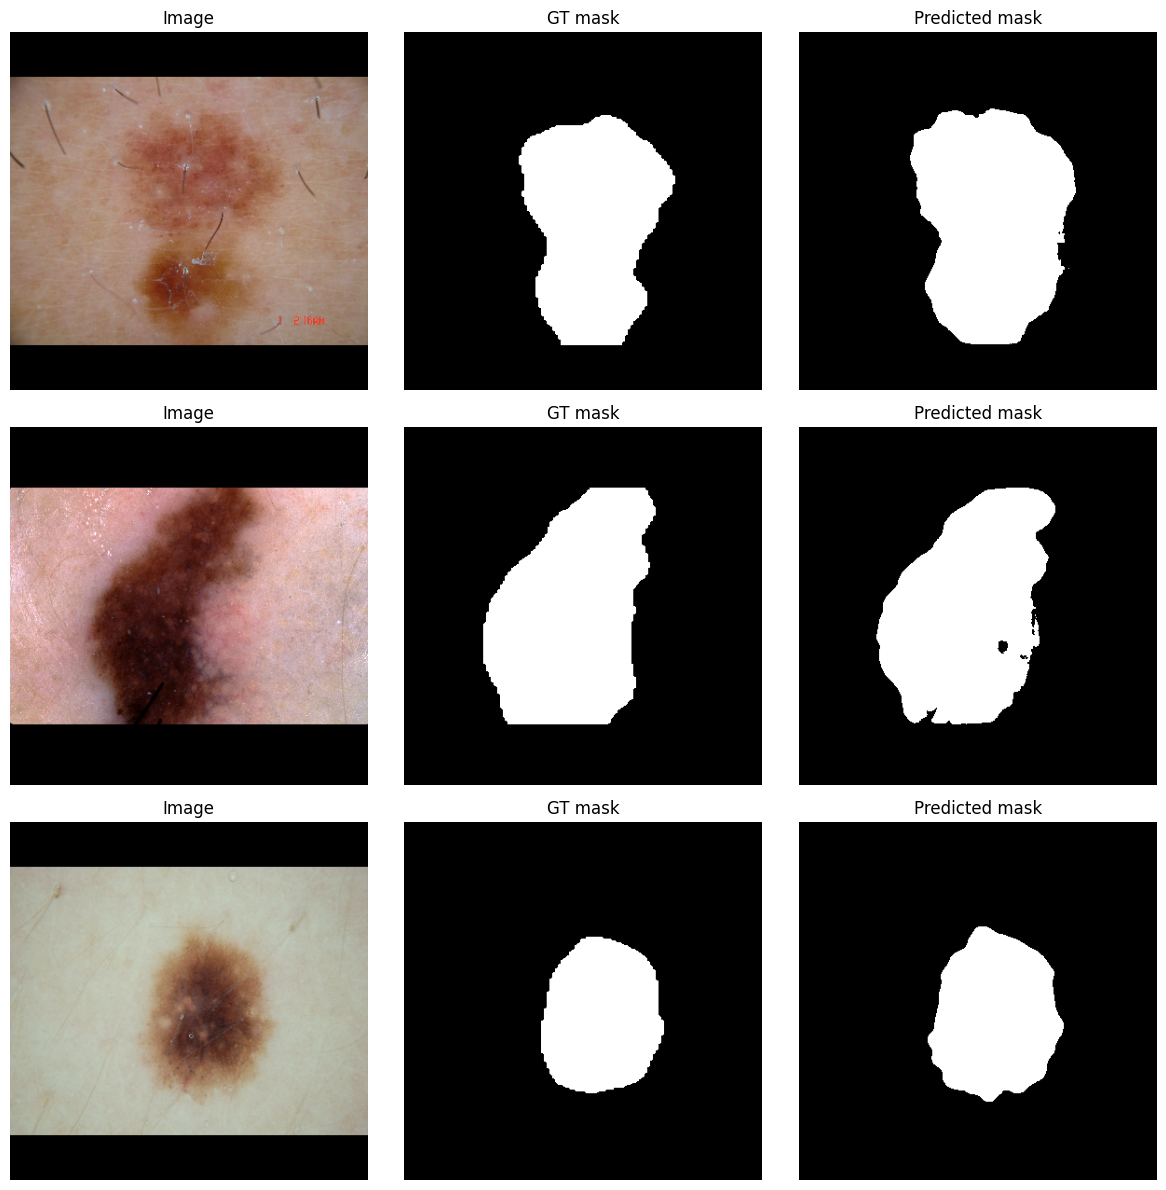

In [9]:

model.load_state_dict(torch.load(Path(CONFIG["output_dir"]) / "best_unet.pt", map_location=DEVICE))
model.eval()

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
idxs = random.sample(range(len(val_ds)), min(3, len(val_ds)))
for row, idx in enumerate(idxs):
    image_t, mask_t = val_ds[idx]
    with torch.no_grad():
        pred = torch.sigmoid(model(image_t.unsqueeze(0).to(DEVICE)))[0, 0].cpu().numpy()
    img_show = image_t.permute(1, 2, 0).numpy()
    img_show = (img_show * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406]))
    img_show = np.clip(img_show, 0, 1)
    axes[row, 0].imshow(img_show); axes[row, 0].set_title("Image"); axes[row, 0].axis("off")
    axes[row, 1].imshow(mask_t[0].numpy(), cmap="gray"); axes[row, 1].set_title("GT mask"); axes[row, 1].axis("off")
    axes[row, 2].imshow(pred > 0.5, cmap="gray"); axes[row, 2].set_title("Predicted mask"); axes[row, 2].axis("off")
plt.tight_layout()
plt.savefig(Path(CONFIG["output_dir"]) / "seg_qualitative_check.png", dpi=120)
plt.show()


## 8. Export

`best_unet.pt` is the artifact the classification notebook needs. After running:
1. Save this notebook's version (so `/kaggle/working/artifacts_seg/` is persisted as output).
2. Go to the notebook's Output tab → "New Dataset" → create e.g. `unet-lesion-segmentation`.
3. In the classification notebook, add that dataset as an input; point
   `CONFIG["unet_checkpoint"]` at `/kaggle/input/unet-lesion-segmentation/best_unet.pt`.


In [10]:

with open(Path(CONFIG["output_dir"]) / "seg_config.json", "w") as f:
    json.dump(CONFIG, f, indent=2)
print("Segmentation artifacts saved to:", CONFIG["output_dir"])
for p in sorted(Path(CONFIG["output_dir"]).glob("*")):
    print(" -", p.name)


Segmentation artifacts saved to: /kaggle/working/artifacts_seg
 - best_unet.pt
 - final_metric.json
 - seg_config.json
 - seg_qualitative_check.png
 - seg_training_history.csv
